<a href="https://colab.research.google.com/github/adilkachhi25/ML_project/blob/main/GenderClassification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub
elakiricoder_gender_classification_dataset_path = kagglehub.dataset_download('elakiricoder/gender-classification-dataset')

print('Data source import complete.')


100%|██████████| 19.0k/19.0k [00:00<00:00, 5.77MB/s]

Extracting files...
Data source import complete.


# <h2><i> *Importing and Information Gathering*

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline
sns.set_palette('viridis')
import random

In [ ]:
df=pd.read_csv('/kaggle/input/gender-classification-dataset/gender_classification_v7.csv')

In [ ]:
df.sample(6)

,long_hair,forehead_width_cm,forehead_height_cm,nose_wide,nose_long,lips_thin,distance_nose_to_lip_long,gender
2604,1,12.3,5.6,0,0,0,0,Female
478,1,13.2,6.0,0,0,0,0,Female
2568,1,14.3,7.0,1,1,1,0,Male
2559,1,13.3,6.2,0,0,0,0,Female
2523,0,14.3,5.2,0,0,1,0,Female
1556,1,12.4,5.1,0,0,0,0,Female


In [ ]:
print(f" The Number of columns are {df.shape[1]} and rows are {df.shape[0]}")

 The Number of columns are 8 and rows are 5001


In [ ]:
# Changing the columns name
df.rename(columns={'forehead_width_cm':'forehead_width',
                   'forehead_height_cm':'forehead_height',
                   'distance_nose_to_lip_long':'dist_nose-lip'},inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5001 entries, 0 to 5000
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   long_hair        5001 non-null   int64  
 1   forehead_width   5001 non-null   float64
 2   forehead_height  5001 non-null   float64
 3   nose_wide        5001 non-null   int64  
 4   nose_long        5001 non-null   int64  
 5   lips_thin        5001 non-null   int64  
 6   dist_nose-lip    5001 non-null   int64  
 7   gender           5001 non-null   object 
dtypes: float64(2), int64(5), object(1)
memory usage: 312.7+ KB


In [ ]:
print(f" Number of Duplicated values are {df.duplicated().sum()}")

 Number of Duplicated values are 1768


In [ ]:
# Checking consistency and validity of data
print(f" Gender = {df.gender.unique()}")
print(f" Nose Wide = {df.nose_wide.unique()}")
print(f" Nose Long = {df.nose_long.unique()}")
print(f" Lips Thin = {df.lips_thin.unique()}")
print(f" Distance Between Nose and Lips = {df['dist_nose-lip'].unique()}")

 Gender = ['Male' 'Female']
 Nose Wide = [1 0]
 Nose Long = [0 1]
 Lips Thin = [1 0]
 Distance Between Nose and Lips = [1 0]


<h5><i>Conclusion :- </h5>
As the data in not that complicated it is having categorical features more than the numerical ones. Data follows the validation and consistency accross it . No need to perform any type of sampling as the number of females and males are almost equal. But the biggest problem withing it have more the 34% of the data is duplicate. Which will make the model more bias and not good for the future prediction .

# <h2><i>*Exploration and Analysis*

In [ ]:
# Total counts of males and females in the datasets
df.gender.value_counts()

gender
Female    2501
Male      2500
Name: count, dtype: int64

In [ ]:
# Average forehead width and height according to the gender
print("Average Forehead Width in both Gender")
df.groupby('gender').forehead_width.mean()

Average Forehead Width in both Gender


gender
Female    12.811675
Male      13.551440
Name: forehead_width, dtype: float64

In [ ]:
print("Average Forehead Height in both Gender")
df.groupby('gender').forehead_height.mean()

Average Forehead Height in both Gender


gender
Female    5.796321
Male      6.096360
Name: forehead_height, dtype: float64

In [ ]:
# Percentage of people having long hair
df.long_hair.count()

5001

In [ ]:
print(f"Percentage of people having long hair {round(((df.long_hair[df.long_hair==1].count()/df.long_hair.count())*100),2)} %")

Percentage of people having long hair 86.96 %


In [ ]:
# Among the people with Long nose , how many people also have distance between the lip to nose long ?

df[(df.nose_long==1) & (df['dist_nose-lip']==1)]

,long_hair,forehead_width,forehead_height,nose_wide,nose_long,lips_thin,dist_nose-lip,gender
2,0,11.8,6.3,1,1,1,1,Male
3,0,14.4,6.1,0,1,1,1,Male
5,1,13.0,6.8,1,1,1,1,Male
10,0,12.5,5.4,1,1,1,1,Male
11,1,15.5,5.8,1,1,1,1,Male
...,...,...,...,...,...,...,...,...
4987,1,12.1,6.2,1,1,1,1,Male
4992,1,14.1,7.0,1,1,1,1,Male
4994,1,12.9,7.0,1,1,1,1,Male
4995,1,12.3,6.9,0,1,1,1,Male


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

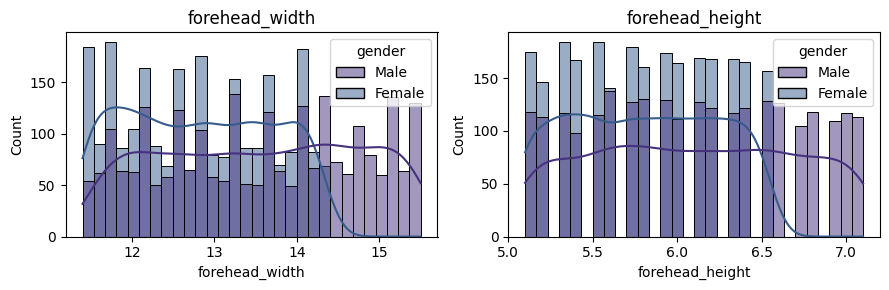

In [ ]:
fig,ax=plt.subplots(1,2,figsize=(9,3))
ax=ax.flatten()
for i,cols in enumerate(df.select_dtypes('float')):
    sns.histplot(kde=True, data=df, x=cols,ax=ax[i],hue='gender',bins=30)
    ax[i].set_title(cols)
plt.tight_layout()
plt.show()

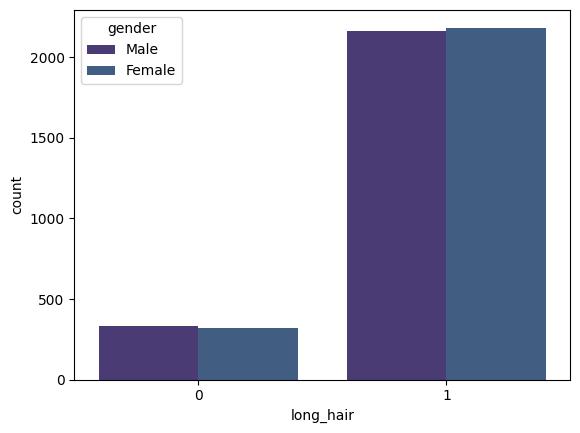

In [ ]:
# Presence of long hair varying accross the genders

sns.countplot(data=df,x='long_hair',hue='gender')
plt.show()

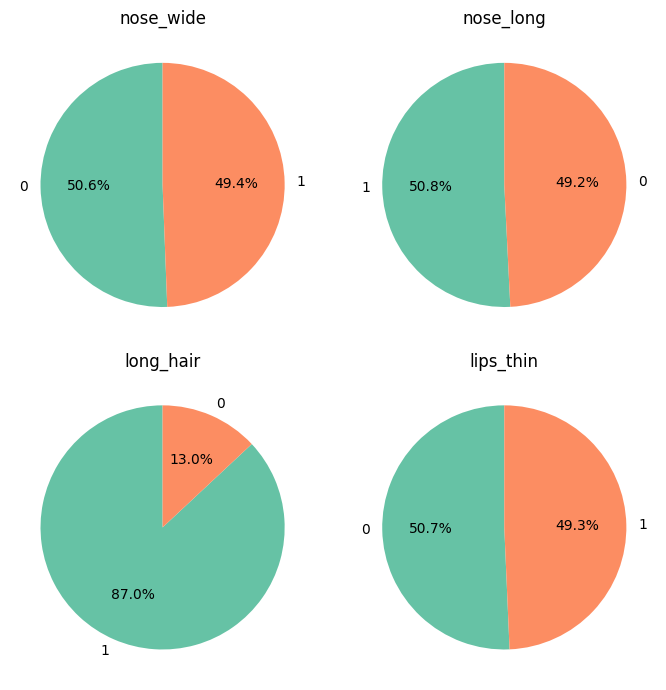

In [ ]:
# Proportion of people having wide nose , long hair , long nose , thin lips

fig,ax=plt.subplots(2,2,figsize=(7,7))
ax=ax.flatten()


for i,cols in enumerate(['nose_wide','nose_long','long_hair','lips_thin']):
    counts=df[cols].value_counts()
    colors = sns.color_palette('Set2', len(counts))
    ax[i].pie(counts,labels=counts.index,autopct='%1.1f%%',startangle=90,colors=colors)
    ax[i].set_title(cols)
plt.tight_layout()
plt.show()

In [ ]:
tf=df.copy()
tf.replace({'Male':1,'Female':0},inplace=True)

/tmp/ipykernel_47/1722726761.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tf.replace({'Male':1,'Female':0},inplace=True)


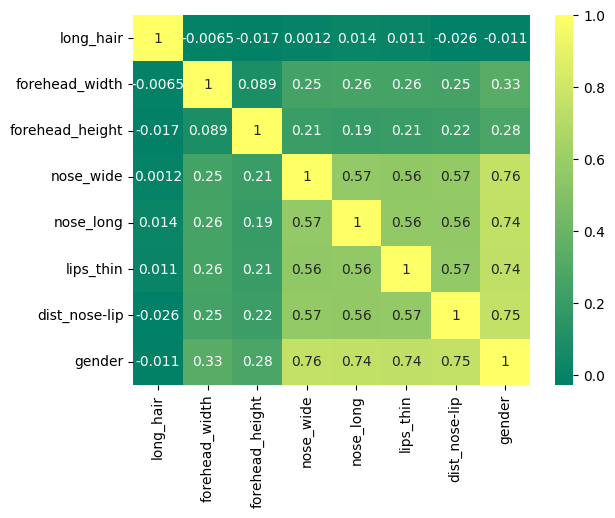

In [ ]:
sns.heatmap(tf.corr(),annot=True,cmap='summer')
plt.show()

# <h4><i> Conclusion :- </i>
-> Height and width of the nose matters the most than as of forehead for gender classification. <br>
-> Thin lips , Long hair doesn't contribute towards the gender disrimination .

# <h2><i> *Model Building and Evaluation*

In [ ]:
from sklearn.model_selection import GridSearchCV , train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier , RandomForestClassifier , AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder , StandardScaler ,LabelEncoder
from sklearn.neighbors import KNeighborsClassifier

<h4> <i> Without Dropping the duplicate values </h4>

In [ ]:
X=df.iloc[:,:-1]
y=df['gender']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)
print(f"Training set size {X_train.shape[0]} and \n testing set size {y_test.shape[0]}")

Training set size 4000 and 
 testing set size 1001


In [ ]:
label=LabelEncoder()
y_train_trf=label.fit_transform(y_train)
y_test_trf=label.transform(y_test)


cols=ColumnTransformer(
    [
        ('std',StandardScaler(),['long_hair','forehead_width','forehead_height','nose_wide',
                                 'nose_long','lips_thin','dist_nose-lip'])
    ]
    ,remainder='passthrough'
)

In [ ]:
pipeline1=Pipeline(
    [
        ('preprocess',cols),
        ('model',LogisticRegression(max_iter=200))
    ]
)

In [ ]:
pipeline1.fit(X_train,y_train_trf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['long_hair',
                                                   'forehead_width',
                                                   'forehead_height',
                                                   'nose_wide', 'nose_long',
                                                   'lips_thin',
                                                   'dist_nose-lip'])])),
                ('model', LogisticRegression(max_iter=200))])

In [ ]:
colormaps = [
    'Blues', 'Reds', 'Greens', 'Purples', 'Oranges', 'Greys',
    'YlOrBr', 'YlOrRd', 'YlGn', 'YlGnBu', 'OrRd', 'PuRd', 'RdPu', 'BuPu',
    'GnBu', 'PuBu', 'PuBuGn', 'BuGn', 'YlGnBu', 'coolwarm', 'viridis',
    'plasma', 'inferno', 'magma', 'cividis', 'cubehelix', 'Spectral',
    'Pastel1', 'Pastel2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20',
    'Accent', 'Dark2', 'Paired', 'flag', 'prism', 'ocean', 'terrain',
    'gist_earth', 'gist_stern', 'gnuplot', 'gnuplot2', 'CMRmap', 'cubehelix'
]


In [ ]:
def prediction(obj):
    y_score=obj.predict(X_test)
    print(f" Accuracy Score {round((accuracy_score(y_true=y_test_trf,y_pred=y_score)),2)*100} %")
    print()
    print()
    fig,ax=plt.subplots(1,2,figsize=(11,4))
    ax=ax.flatten()
    cmap_choice = random.choice(colormaps)
    sns.heatmap(confusion_matrix(y_true=y_test_trf,y_pred=y_score),cmap=cmap_choice,annot=True,ax=ax[0])
    ax[1].set_title("Confusion Matrix")
    y_score_proba=obj.predict_proba(X_test)[:,1]
    fpr,tpr,threshold=roc_curve(y_true=y_test_trf,y_score=y_score_proba)
    ax[1].plot(fpr,tpr)
    ax[1].set_xlabel("False Positive Rate")
    ax[1].set_ylabel("True Positive Rate")
    ax[1].set_title("Roc Curve")
    plt.show()


 Accuracy Score 97.0 %




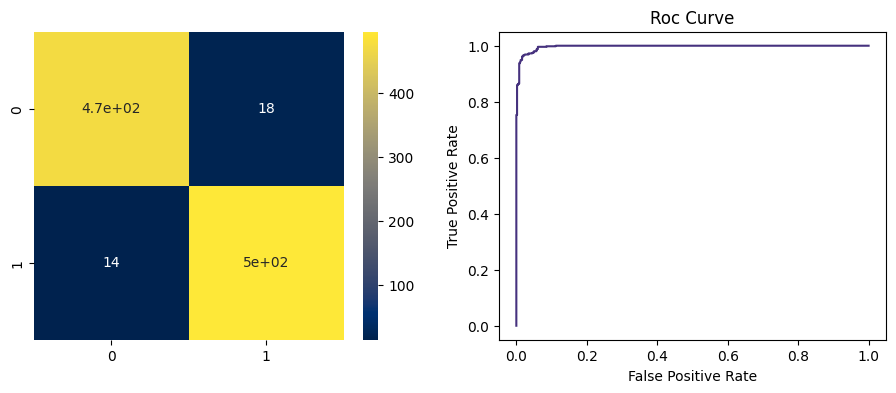

In [ ]:
prediction(pipeline1)

In [ ]:
pipeline2=Pipeline(
    [
        ('preprocess',cols),
        ('model',KNeighborsClassifier(n_neighbors=4,metric='euclidean'))
    ]
)

In [ ]:
pipeline2.fit(X_train,y_train_trf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['long_hair',
                                                   'forehead_width',
                                                   'forehead_height',
                                                   'nose_wide', 'nose_long',
                                                   'lips_thin',
                                                   'dist_nose-lip'])])),
                ('model',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=4))])

 Accuracy Score 97.0 %




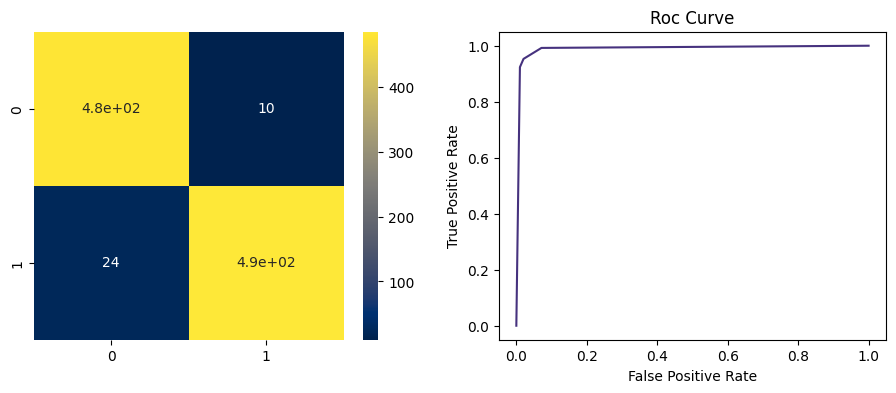

In [ ]:
prediction(pipeline2)

As Data have more than 34% duplicates values model is getting bias and doing the right prediction of having 97% of accuracy score . This is the clear indication of overfitting . So we skipping the part of ensemble learning and further evulation as model is performing well . Let's see how it perform on the raw data without any duplicates

<h4> <i> Without any duplicated values </h4>

In [ ]:
tf=df.copy()

In [ ]:
tf.duplicated().sum()

1768

In [ ]:
tf.drop_duplicates(inplace=True)

In [ ]:
tf.shape

(3233, 8)

In [ ]:
tf.duplicated().sum()

0

In [ ]:
X=tf.iloc[:,:-1]
y=tf['gender']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)
print(f" Training Set is {X_train.shape[0]} and \n Testing is {y_test.shape[0]}")

 Training Set is 2586 and 
 Testing is 647


In [ ]:
label=LabelEncoder()
y_train_trf=label.fit_transform(y_train)
y_test_trf=label.transform(y_test)

In [ ]:
# Training the pipeline of logisitic regression again with new one

pipeline1.fit(X_train,y_train_trf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['long_hair',
                                                   'forehead_width',
                                                   'forehead_height',
                                                   'nose_wide', 'nose_long',
                                                   'lips_thin',
                                                   'dist_nose-lip'])])),
                ('model', LogisticRegression(max_iter=200))])

 Accuracy Score 96.0 %




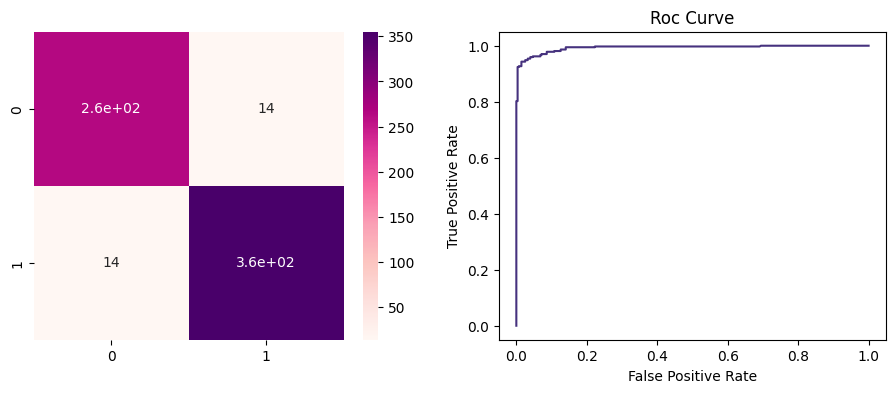

In [ ]:
prediction(pipeline1)

In [ ]:
pipeline2.fit(X_train,y_train_trf)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('std', StandardScaler(),
                                                  ['long_hair',
                                                   'forehead_width',
                                                   'forehead_height',
                                                   'nose_wide', 'nose_long',
                                                   'lips_thin',
                                                   'dist_nose-lip'])])),
                ('model',
                 KNeighborsClassifier(metric='euclidean', n_neighbors=4))])

 Accuracy Score 94.0 %




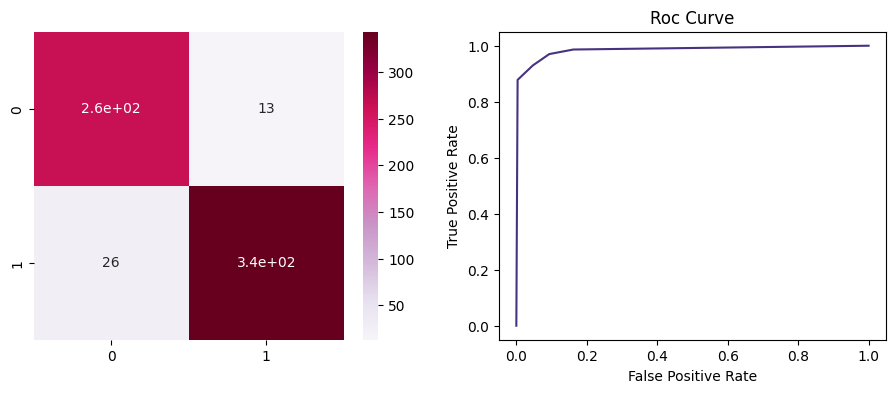

In [ ]:
prediction(pipeline2)

Final Conclusion :- All the relations mostly contributes towards the final features and correlated. There is no need to extra preprocessing or anything . There is an absence of outliers. Dataset is suitable for the beginner .

Future Improvements :- As there is no need do any further tunning or anything . May be in future model will get pickle and deployed under streamlit application .

In [ ]:

custom_male_data = pd.DataFrame([[1, 14.5, 6.5, 1, 1, 1, 1]],
                                columns=X.columns)

prediction_encoded = pipeline1.predict(custom_male_data)
prediction_label = label.inverse_transform(prediction_encoded)

print(f"The model classifies this candidate as: {prediction_label[0]}")

The model classifies this candidate as: Male


In [ ]:

custom_female_data = pd.DataFrame([[1, 12.1, 5.4, 0, 0, 0, 0]],
                                  columns=X.columns)


prediction_encoded = pipeline1.predict(custom_female_data)
prediction_label = label.inverse_transform(prediction_encoded)

print(f"The model classifies this candidate as: {prediction_label[0]}")

The model classifies this candidate as: Female
